In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/cifar-10/trainLabels.csv
/kaggle/input/competitions/cifar-10/sampleSubmission.csv
/kaggle/input/competitions/cifar-10/test.7z
/kaggle/input/competitions/cifar-10/train.7z


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
labels = pd.read_csv('/kaggle/input/competitions/cifar-10/trainLabels.csv')

labels.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [4]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y = le.fit_transform(labels['label'])

In [5]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.3/495.3 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 6.7 MB/s eta 0:00:00


In [6]:
import py7zr

with py7zr.SevenZipFile('/kaggle/input/competitions/cifar-10/train.7z', mode='r') as z:
    z.extractall(path='/kaggle/working/')

In [7]:
os.listdir('/kaggle/working')

['__notebook__.ipynb', 'train']

In [8]:
os.listdir('/kaggle/working/train')[:5]

['30522.png', '33703.png', '10815.png', '9329.png', '20673.png']

In [9]:
train_dir = '/kaggle/working/train'

In [10]:
images = []

for img_id in labels['id']:
    
    path = os.path.join(train_dir, f'{img_id}.png')
    
    img = Image.open(path)
    
    img_array = np.array(img)
    
    images.append(img_array)

## Converting it into numpy array

In [11]:
X = np.array(images)

print(X.shape)

(50000, 32, 32, 3)


In [12]:
X = X.reshape(len(X), -1)

print(X.shape)

(50000, 3072)


### Displaying Image

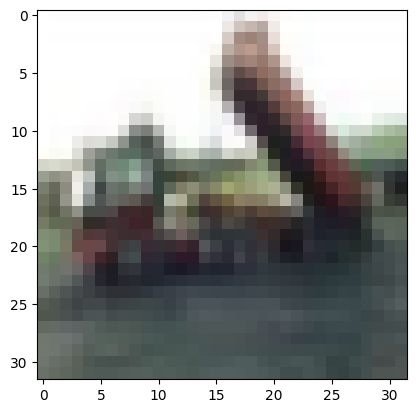

id           3
label    truck
Name: 2, dtype: object


In [13]:
import matplotlib.pyplot as plt

plt.imshow(images[2])

plt.show()

print(labels.iloc[2])

### Showing Multiple Images

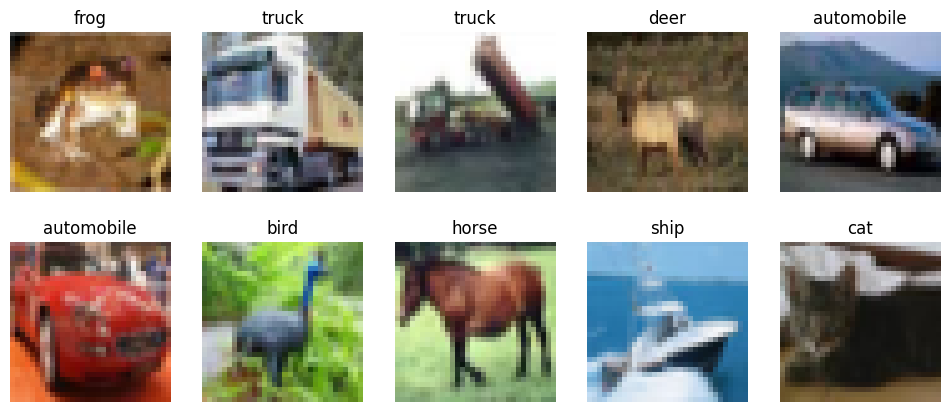

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i, ax in enumerate(axes.flat):
    
    ax.imshow(images[i])
    
    ax.set_title(labels['label'][i])
    
    ax.axis('off')

plt.show()

## Images Pixel

In [15]:
print(images[0])

[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]


# Converting inyo dataframe

In [16]:
import pandas as pd

df = pd.DataFrame(X)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,3062,3063,3064,3065,3066,3067,3068,3069,3070,3071
0,59,62,63,43,46,45,50,48,43,68,...,104,216,184,140,151,118,84,123,92,72
1,154,177,187,126,137,136,105,104,95,102,...,136,143,133,139,143,134,142,143,133,144
2,255,255,255,253,253,253,253,253,253,253,...,79,78,85,83,79,85,83,80,86,84
3,28,25,10,37,34,19,38,35,20,42,...,38,54,47,28,63,56,37,72,65,46
4,170,180,198,168,178,196,177,185,203,183,...,78,75,79,82,71,75,78,73,77,80


In [17]:
df.shape

(50000, 3072)

## Add Target Column -> y

In [18]:
df['target']=y

In [19]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,target
0,59,62,63,43,46,45,50,48,43,68,...,216,184,140,151,118,84,123,92,72,6
1,154,177,187,126,137,136,105,104,95,102,...,143,133,139,143,134,142,143,133,144,9
2,255,255,255,253,253,253,253,253,253,253,...,78,85,83,79,85,83,80,86,84,9
3,28,25,10,37,34,19,38,35,20,42,...,54,47,28,63,56,37,72,65,46,4
4,170,180,198,168,178,196,177,185,203,183,...,75,79,82,71,75,78,73,77,80,1


In [20]:
df['target']

0        6
1        9
2        9
3        4
4        1
        ..
49995    2
49996    6
49997    9
49998    1
49999    1
Name: target, Length: 50000, dtype: int64

# Train Test Split

In [21]:
X = df.drop('target', axis=1)

y = df['target']

In [22]:
# Checking Our dataset Contain category features or not

categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index([], dtype='object')


In [23]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
# StandardScaler
scale = StandardScaler()
x_train_scale = scale.fit_transform(x_train)
x_test_scale = scale.transform(x_test)

In [25]:
# Model Trainning

In [26]:
model = LogisticRegression()
model.fit(x_train_scale,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [27]:
y_pred = model.predict(x_test_scale)

In [28]:
y_pred

array([3, 8, 8, ..., 8, 4, 6])

In [29]:
# Accuracy

print(accuracy_score(y_test,y_pred))

0.3935


## Principle Component Analysis

In [30]:
pca = PCA(n_components=0.95)

x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [31]:
lr = LogisticRegression()
lr.fit(x_train_pca,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
y_pred_new = lr.predict(x_test_pca)

In [33]:
print(accuracy_score(y_test,y_pred))

0.3935


In [34]:
print(pca.n_components_)

217
